# Vulnerability Detection Analysis

Analysis of vulnerability detection experiments across 4 agent designs (NoAgent, SA, DA, MA),
4 models (Qwen3-4B, Qwen3-30B, Nemotron-Nano-8B, Nemotron-Super-49B),
2 modes (instruct, thinking), and 2 prompting strategies (zero-shot, few-shot).

**Dataset**: VulTrial-870 (435 vulnerable + 435 safe samples)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

BASE_DIR = Path('..').resolve()
RESULTS_DIR = BASE_DIR / 'results'
OUTPUT_DIR = BASE_DIR / 'notebooks' / 'results'
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load Data

In [2]:
# Load consolidated performance and emissions
perf_df = pd.read_csv(RESULTS_DIR / 'consolidated_performance.csv')
emissions_df = pd.read_csv(RESULTS_DIR / 'consolidated_emissions.csv')

# Filter to vulnerability detection on VulTrial-486
df = perf_df[(perf_df['task'] == 'vulnerability_detection') & (perf_df['dataset'] == 'VulTrial-870')].copy()

# Add percentage columns
for col in ['accuracy', 'precision', 'recall', 'f1_score']:
    df[f'{col}_pct'] = df[col] * 100

# Merge emissions
emit_cols = ['model', 'parameters_b', 'design', 'task', 'dataset', 'mode', 'prompting',
             'total_energy_kwh', 'total_emissions_kg', 'total_duration_s', 'duration_hours']
df = pd.merge(df, emissions_df[emit_cols], 
              on=['model', 'parameters_b', 'design', 'task', 'dataset', 'mode', 'prompting'],
              how='left')

# Short model labels
model_label = {
    'Qwen3-4B-Instruct': '4B Inst', 'Qwen3-4B-Thinking': '4B Think',
    'Qwen3-30B-A3B-Instruct': '30B Inst', 'Qwen3-30B-A3B-Thinking': '30B Think',
    'Nemotron-Nano-8B': None, 'Nemotron-Super-49B': None,
}
df['model_short'] = df['model'].map(model_label)
# Nemotron: append mode since same model name for instruct/thinking
df.loc[df['model_short'].isna() & (df['model'].str.contains('Nano-8B')), 'model_short'] = \
    df.loc[df['model_short'].isna() & (df['model'].str.contains('Nano-8B')), 'mode'].map({'instruct': '8B Inst', 'thinking': '8B Think'})
df.loc[df['model_short'].isna() & (df['model'].str.contains('Super-49B')), 'model_short'] = \
    df.loc[df['model_short'].isna() & (df['model'].str.contains('Super-49B')), 'mode'].map({'instruct': '49B Inst', 'thinking': '49B Think'})

print(f'Experiments: {len(df)}')
print(f'\nBy design: {df["design"].value_counts().to_dict()}')
print(f'By model family: {df["model_family"].value_counts().to_dict()}')
print(f'By mode: {df["mode"].value_counts().to_dict()}')
print(f'By prompting: {df["prompting"].value_counts().to_dict()}')

Experiments: 64

By design: {'DA': 16, 'MA': 16, 'NoAgent': 16, 'SA': 16}
By model family: {'Nemotron': 32, 'Qwen': 32}
By mode: {'instruct': 32, 'thinking': 32}
By prompting: {'few-shot': 32, 'zero-shot': 32}


## 2. Color Configuration

In [3]:
DESIGN_COLORS = {'NoAgent': '#f39c12', 'SA': '#2ecc71', 'DA': '#3498db', 'MA': '#e74c3c'}
DESIGN_ORDER = ['NoAgent', 'SA', 'DA', 'MA']
MODEL_COLORS = {4: '#3498db', 8: '#00bcd4', 30: '#9b59b6', 49: '#e91e63'}
MODE_COLORS = {'instruct': '#3498db', 'thinking': '#e74c3c'}
PROMPT_COLORS = {'zero-shot': '#95a5a6', 'few-shot': '#2c3e50'}

## 3. Overview: Performance by Design

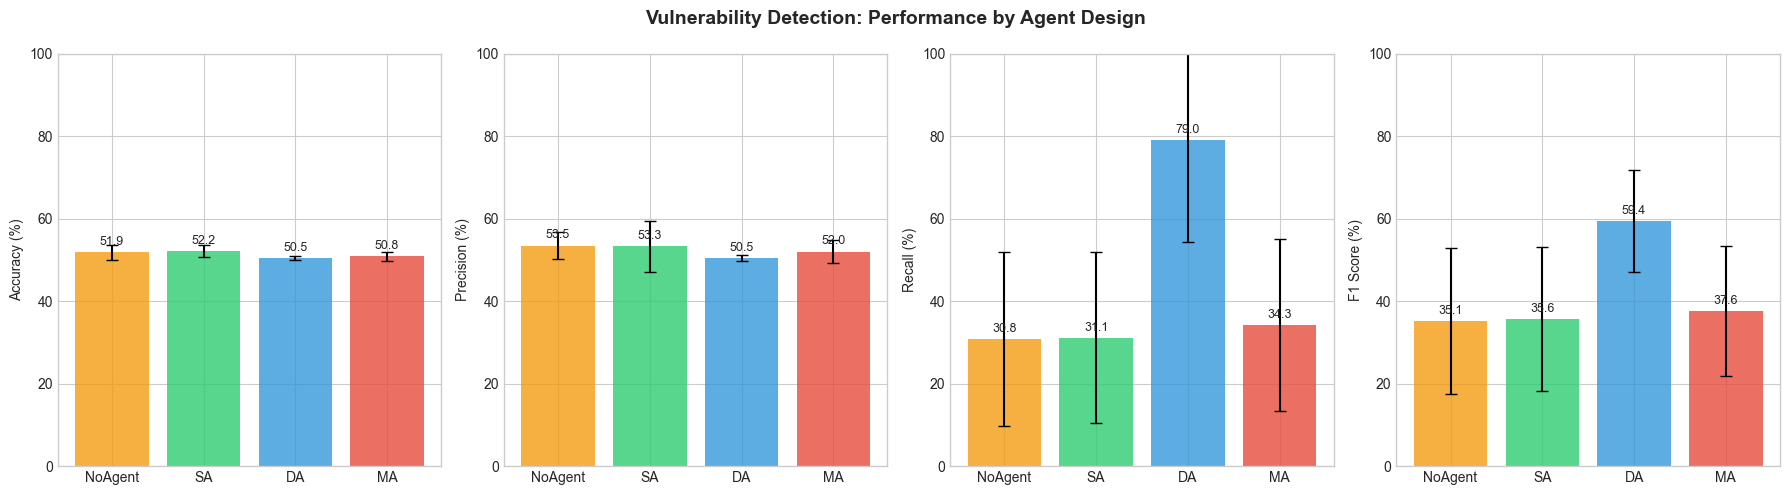

In [4]:
# Bar chart: F1 by design
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['accuracy_pct', 'precision_pct', 'recall_pct', 'f1_score_pct']
metric_labels = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']

for ax, metric, label in zip(axes, metrics, metric_labels):
    means = df.groupby('design')[metric].mean().reindex(DESIGN_ORDER)
    stds = df.groupby('design')[metric].std().reindex(DESIGN_ORDER)
    bars = ax.bar(range(len(DESIGN_ORDER)), means, yerr=stds, capsize=4,
                  color=[DESIGN_COLORS[d] for d in DESIGN_ORDER], alpha=0.8)
    ax.set_xticks(range(len(DESIGN_ORDER)))
    ax.set_xticklabels(DESIGN_ORDER)
    ax.set_ylabel(label)
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}',
                ha='center', va='bottom', fontsize=9)

fig.suptitle('Vulnerability Detection: Performance by Agent Design', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_design_comparison.png', bbox_inches='tight')
plt.show()

In [5]:
# Summary table by design
design_summary = df.groupby('design')[metrics].agg(['mean', 'std', 'min', 'max']).round(2)
design_summary = design_summary.reindex(DESIGN_ORDER)
print('Performance by Design (VulTrial-870):')
print(design_summary.to_string())

Performance by Design (VulTrial-870):
        accuracy_pct                     precision_pct                     recall_pct                      f1_score_pct                     
                mean   std    min    max          mean   std    min    max       mean    std    min    max         mean    std    min    max
design                                                                                                                                      
NoAgent        51.86  1.84  48.85  54.03         53.47  3.19  48.47  59.50      30.83  21.12   0.46  74.48        35.08  17.71   0.91  61.89
SA             52.17  1.42  49.65  54.49         53.25  6.19  33.33  62.30      31.13  20.68   0.23  73.21        35.58  17.43   0.46  61.02
DA             50.45  0.58  49.19  51.50         50.50  0.69  49.53  52.69      78.95  24.58  11.26  98.85        59.37  12.34  18.56  66.56
MA             50.81  1.11  49.31  53.63         52.00  2.69  49.34  58.70      34.27  20.83   6.21  67.59        37

## 4. Model Size Scaling

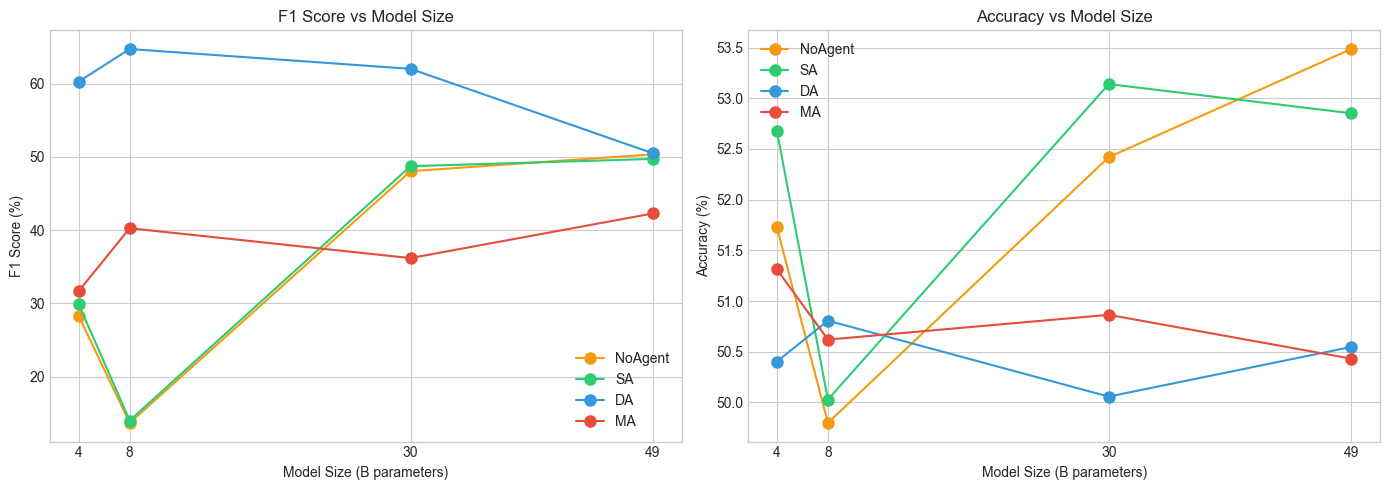

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by model size
ax = axes[0]
for design in DESIGN_ORDER:
    sub = df[df['design'] == design].groupby('parameters_b')['f1_score_pct'].mean()
    ax.plot(sub.index, sub.values, 'o-', label=design, color=DESIGN_COLORS[design], markersize=8)
ax.set_xlabel('Model Size (B parameters)')
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 Score vs Model Size')
ax.legend()
ax.set_xticks([4, 8, 30, 49])

# Accuracy by model size
ax = axes[1]
for design in DESIGN_ORDER:
    sub = df[df['design'] == design].groupby('parameters_b')['accuracy_pct'].mean()
    ax.plot(sub.index, sub.values, 'o-', label=design, color=DESIGN_COLORS[design], markersize=8)
ax.set_xlabel('Model Size (B parameters)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Model Size')
ax.legend()
ax.set_xticks([4, 8, 30, 49])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_model_size_scaling.png', bbox_inches='tight')
plt.show()

## 5. Mode Comparison (Instruct vs Thinking)

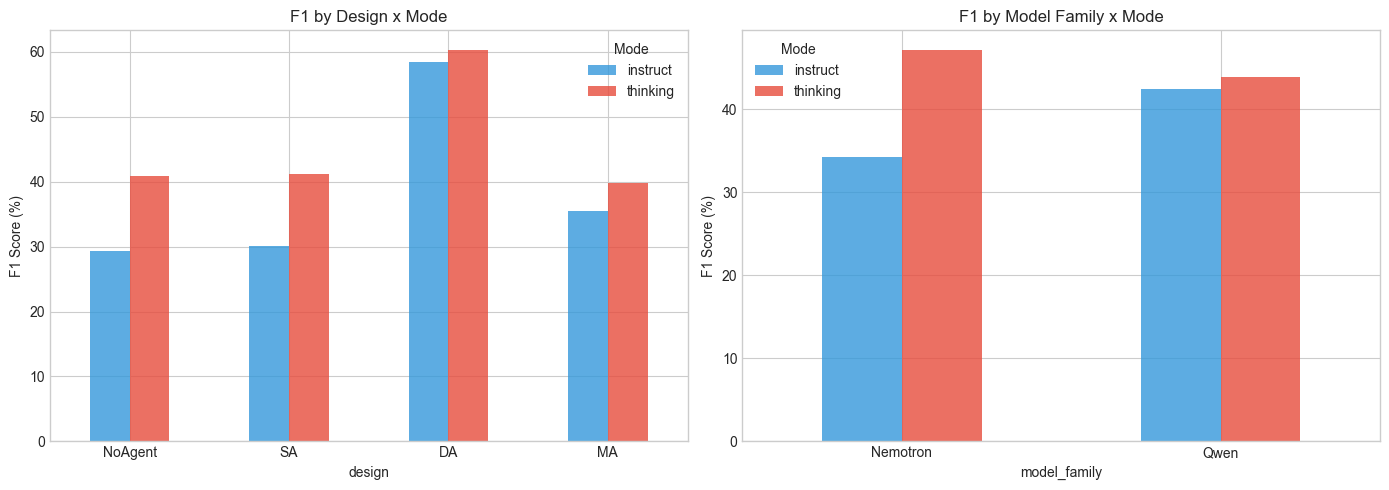

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By mode across designs
ax = axes[0]
mode_design = df.groupby(['design', 'mode'])['f1_score_pct'].mean().unstack()
mode_design = mode_design.reindex(DESIGN_ORDER)
mode_design.plot(kind='bar', ax=ax, color=[MODE_COLORS.get(c, '#999') for c in mode_design.columns], alpha=0.8)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 by Design x Mode')
ax.set_xticklabels(DESIGN_ORDER, rotation=0)
ax.legend(title='Mode')

# By mode across model families
ax = axes[1]
mode_family = df.groupby(['model_family', 'mode'])['f1_score_pct'].mean().unstack()
mode_family.plot(kind='bar', ax=ax, color=[MODE_COLORS.get(c, '#999') for c in mode_family.columns], alpha=0.8)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 by Model Family x Mode')
ax.set_xticklabels(mode_family.index, rotation=0)
ax.legend(title='Mode')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_mode_comparison.png', bbox_inches='tight')
plt.show()

## 6. Prompting Strategy (Zero-shot vs Few-shot)

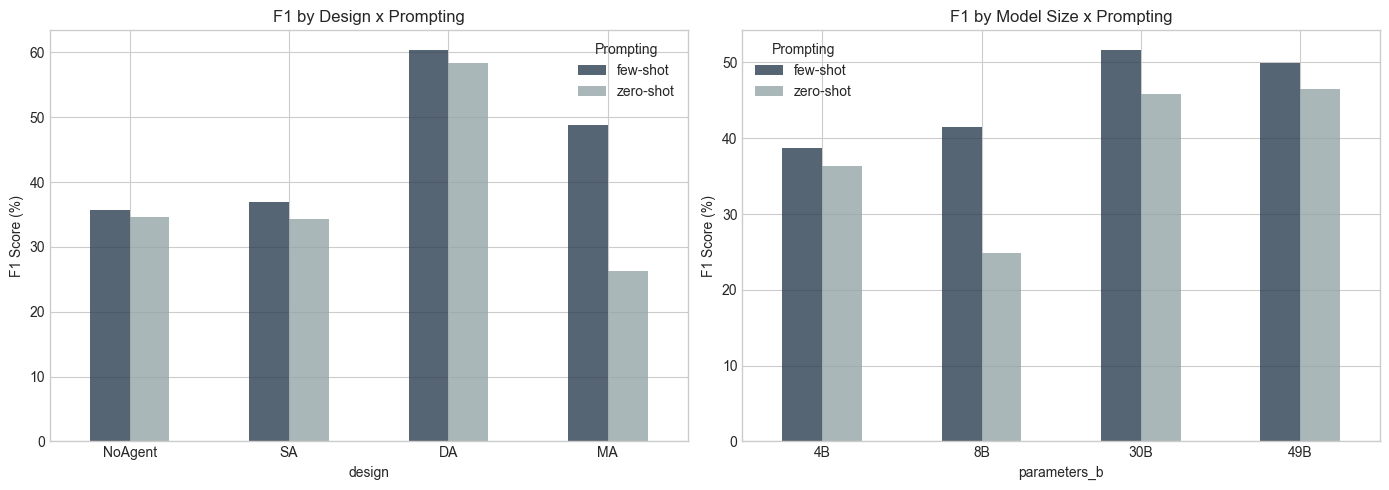

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By prompting across designs
ax = axes[0]
prompt_design = df.groupby(['design', 'prompting'])['f1_score_pct'].mean().unstack()
prompt_design = prompt_design.reindex(DESIGN_ORDER)
prompt_design.plot(kind='bar', ax=ax, color=[PROMPT_COLORS.get(c, '#999') for c in prompt_design.columns], alpha=0.8)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 by Design x Prompting')
ax.set_xticklabels(DESIGN_ORDER, rotation=0)
ax.legend(title='Prompting')

# By prompting across model sizes
ax = axes[1]
prompt_size = df.groupby(['parameters_b', 'prompting'])['f1_score_pct'].mean().unstack()
prompt_size.plot(kind='bar', ax=ax, color=[PROMPT_COLORS.get(c, '#999') for c in prompt_size.columns], alpha=0.8)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 by Model Size x Prompting')
ax.set_xticklabels([f'{s}B' for s in prompt_size.index], rotation=0)
ax.legend(title='Prompting')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_prompting_comparison.png', bbox_inches='tight')
plt.show()

## 7. Full Experiment Heatmap

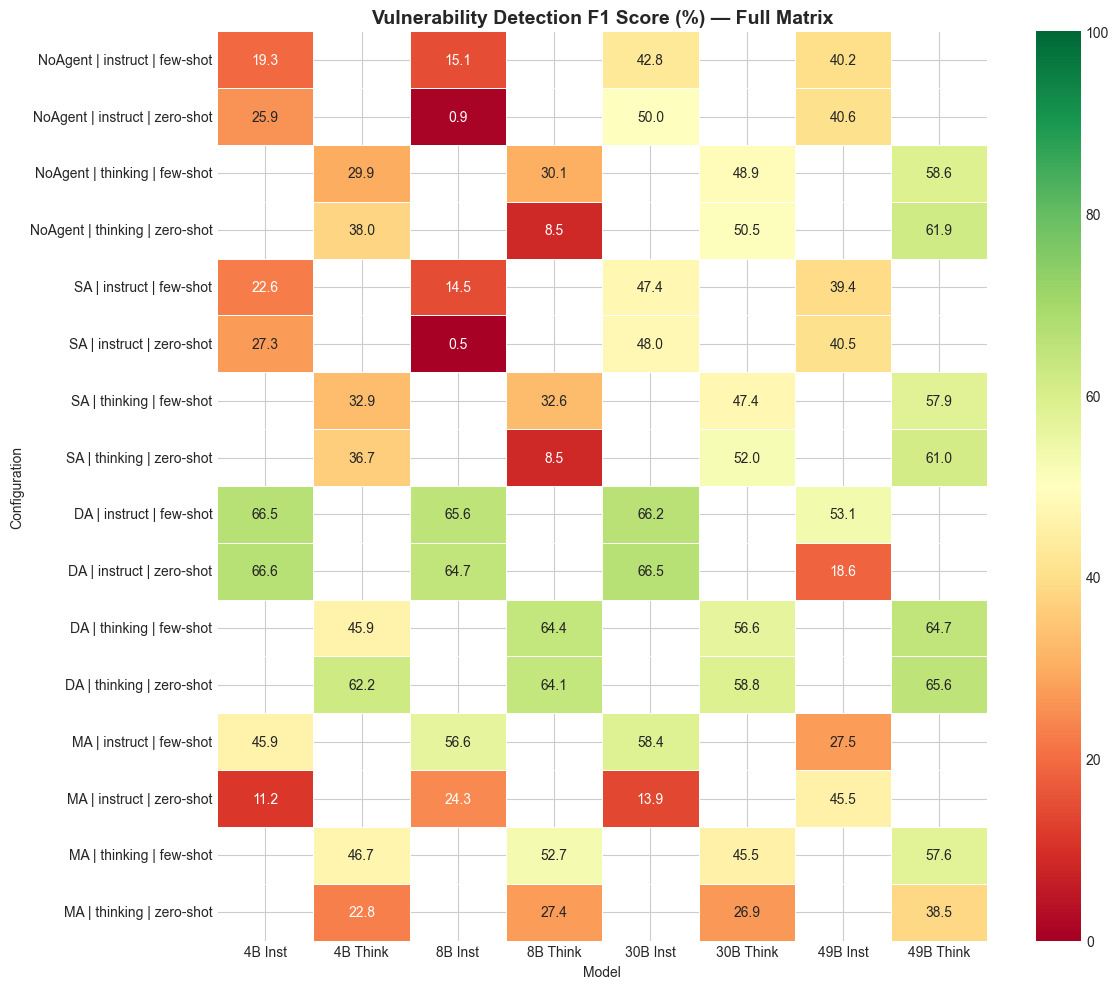

In [9]:
# Create config label: Design | Mode | Prompting
df['config'] = df['design'] + ' | ' + df['mode'] + ' | ' + df['prompting']

# Pivot: config x model
heatmap_data = df.pivot_table(values='f1_score_pct', index='config', columns='model_short',
                              aggfunc='mean')

# Sort by design order
design_sort = {d: i for i, d in enumerate(DESIGN_ORDER)}
heatmap_data['_sort'] = heatmap_data.index.map(lambda x: design_sort.get(x.split(' | ')[0], 99))
heatmap_data = heatmap_data.sort_values('_sort').drop(columns='_sort')

# Reorder columns by model size
col_order = ['4B Inst', '4B Think', '8B Inst', '8B Think', '30B Inst', '30B Think', '49B Inst', '49B Think']
heatmap_data = heatmap_data[[c for c in col_order if c in heatmap_data.columns]]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=0.5, ax=ax, vmin=0, vmax=100)
ax.set_title('Vulnerability Detection F1 Score (%) — Full Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Configuration')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_f1_heatmap.png', bbox_inches='tight')
plt.show()

## 8. Confusion Matrix Analysis

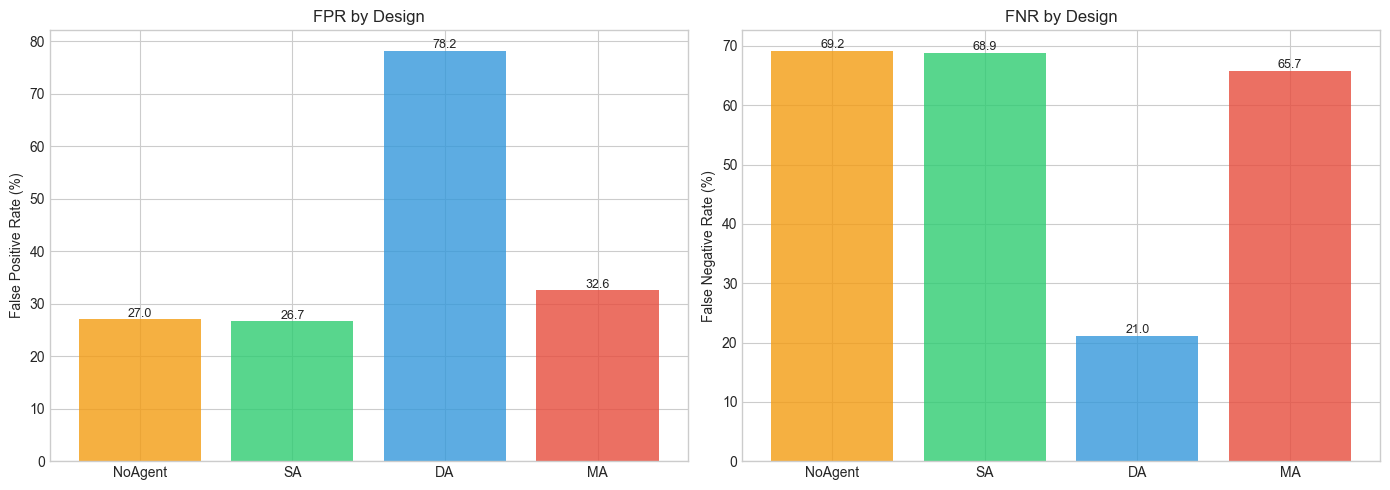

In [10]:
# FPR and FNR by design
df['fpr'] = df['false_positives'] / (df['false_positives'] + df['true_negatives']) * 100
df['fnr'] = df['false_negatives'] / (df['false_negatives'] + df['true_positives']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FPR by design
ax = axes[0]
fpr_means = df.groupby('design')['fpr'].mean().reindex(DESIGN_ORDER)
ax.bar(range(len(DESIGN_ORDER)), fpr_means, color=[DESIGN_COLORS[d] for d in DESIGN_ORDER], alpha=0.8)
ax.set_xticks(range(len(DESIGN_ORDER)))
ax.set_xticklabels(DESIGN_ORDER)
ax.set_ylabel('False Positive Rate (%)')
ax.set_title('FPR by Design')
for i, v in enumerate(fpr_means):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

# FNR by design
ax = axes[1]
fnr_means = df.groupby('design')['fnr'].mean().reindex(DESIGN_ORDER)
ax.bar(range(len(DESIGN_ORDER)), fnr_means, color=[DESIGN_COLORS[d] for d in DESIGN_ORDER], alpha=0.8)
ax.set_xticks(range(len(DESIGN_ORDER)))
ax.set_xticklabels(DESIGN_ORDER)
ax.set_ylabel('False Negative Rate (%)')
ax.set_title('FNR by Design')
for i, v in enumerate(fnr_means):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_fpr_fnr.png', bbox_inches='tight')
plt.show()

## 9. Energy Efficiency

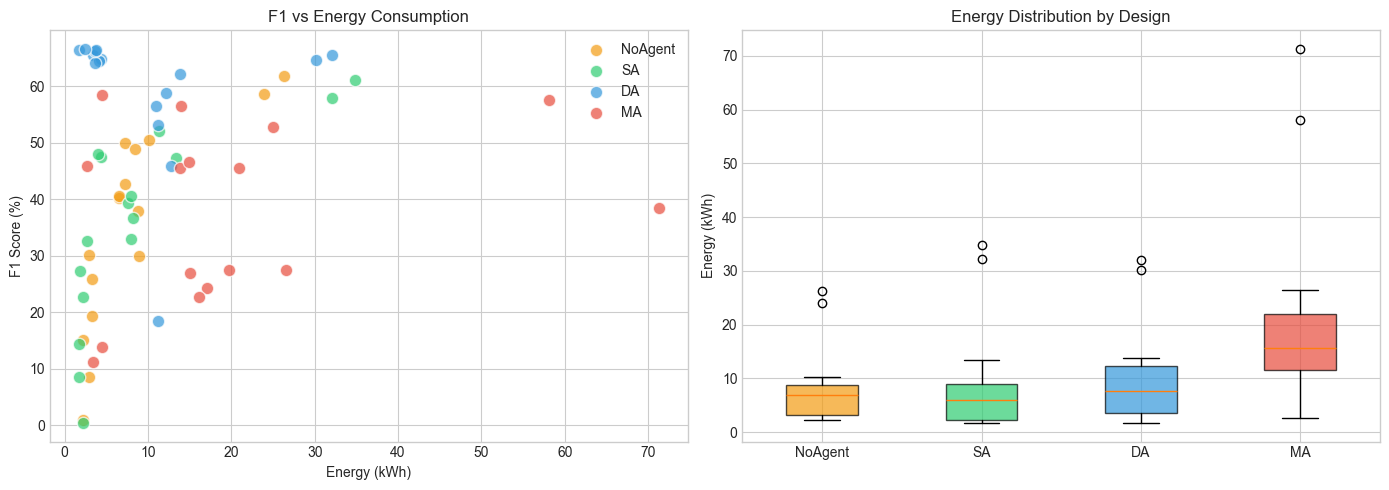

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 vs Energy scatter
ax = axes[0]
for design in DESIGN_ORDER:
    sub = df[df['design'] == design]
    ax.scatter(sub['total_energy_kwh'], sub['f1_score_pct'], 
               c=DESIGN_COLORS[design], label=design, s=80, alpha=0.7, edgecolors='white')
ax.set_xlabel('Energy (kWh)')
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 vs Energy Consumption')
ax.legend()

# Energy by design (boxplot)
ax = axes[1]
design_data = [df[df['design'] == d]['total_energy_kwh'].dropna() for d in DESIGN_ORDER]
bp = ax.boxplot(design_data, patch_artist=True, labels=DESIGN_ORDER)
for patch, design in zip(bp['boxes'], DESIGN_ORDER):
    patch.set_facecolor(DESIGN_COLORS[design])
    patch.set_alpha(0.7)
ax.set_ylabel('Energy (kWh)')
ax.set_title('Energy Distribution by Design')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vuln_energy_analysis.png', bbox_inches='tight')
plt.show()

In [12]:
# Efficiency: F1 per kWh
df['f1_per_kwh'] = df['f1_score_pct'] / df['total_energy_kwh']

print('Top 10 Most Efficient Configs (F1/kWh):')
top_eff = df.nlargest(10, 'f1_per_kwh')[['design', 'model', 'mode', 'prompting', 'f1_score_pct', 'total_energy_kwh', 'f1_per_kwh']]
print(top_eff.to_string(index=False))

print('\nBottom 10 Least Efficient:')
bot_eff = df.nsmallest(10, 'f1_per_kwh')[['design', 'model', 'mode', 'prompting', 'f1_score_pct', 'total_energy_kwh', 'f1_per_kwh']]
print(bot_eff.to_string(index=False))

Top 10 Most Efficient Configs (F1/kWh):
design                  model     mode prompting  f1_score_pct  total_energy_kwh  f1_per_kwh
    DA      Qwen3-4B-Instruct instruct  few-shot       66.4587          1.734068   38.325317
    DA      Qwen3-4B-Instruct instruct zero-shot       66.5625          2.471080   26.936606
    DA       Nemotron-Nano-8B instruct  few-shot       65.5974          3.389258   19.354500
    DA Qwen3-30B-A3B-Instruct instruct  few-shot       66.2005          3.655388   18.110389
    DA Qwen3-30B-A3B-Instruct instruct zero-shot       66.4606          3.719304   17.869094
    DA       Nemotron-Nano-8B thinking zero-shot       64.1156          3.589193   17.863515
    MA      Qwen3-4B-Instruct instruct  few-shot       45.9459          2.634125   17.442565
    DA       Nemotron-Nano-8B thinking  few-shot       64.3983          4.106938   15.680370
    SA      Qwen3-4B-Instruct instruct zero-shot       27.2890          1.847658   14.769506
    DA       Nemotron-Nano-8B 

## 10. Best Configurations

In [13]:
print('Best F1 per design:')
for design in DESIGN_ORDER:
    sub = df[df['design'] == design]
    best = sub.loc[sub['f1_score_pct'].idxmax()]
    print(f'  {design:8s}: F1={best["f1_score_pct"]:.1f}%  Acc={best["accuracy_pct"]:.1f}%  '
          f'{best["model"]}  {best["mode"]}  {best["prompting"]}  ({best["total_energy_kwh"]:.2f} kWh)')

print('\nBest F1 overall:')
best_overall = df.loc[df['f1_score_pct'].idxmax()]
print(f'  F1={best_overall["f1_score_pct"]:.1f}%  Acc={best_overall["accuracy_pct"]:.1f}%  '
      f'{best_overall["design"]} {best_overall["model"]} {best_overall["mode"]} {best_overall["prompting"]}')

Best F1 per design:
  NoAgent : F1=61.9%  Acc=54.0%  Nemotron-Super-49B  thinking  zero-shot  (26.27 kWh)
  SA      : F1=61.0%  Acc=53.3%  Nemotron-Super-49B  thinking  zero-shot  (34.79 kWh)
  DA      : F1=66.6%  Acc=50.7%  Qwen3-4B-Instruct  instruct  zero-shot  (2.47 kWh)
  MA      : F1=58.4%  Acc=51.7%  Qwen3-30B-A3B-Instruct  instruct  few-shot  (4.46 kWh)

Best F1 overall:
  F1=66.6%  Acc=50.7%  DA Qwen3-4B-Instruct instruct zero-shot


## RQ1 Paper Figure: NA-Only F1 Heatmap

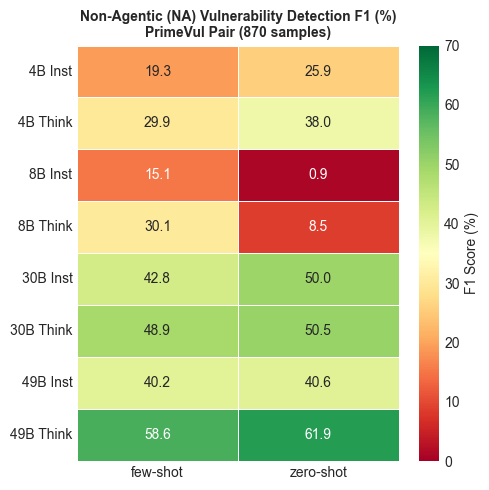

Saved: rq1_vuln_heatmap_na.png/.pdf


In [14]:
# NA-only F1 heatmap for RQ1 paper figure
na_only = df[df['design'] == 'NoAgent'].copy()

na_hm = na_only.pivot_table(values='f1_score_pct', index='model_short',
                            columns='prompting', aggfunc='mean')

row_order = ['4B Inst', '4B Think', '8B Inst', '8B Think',
             '30B Inst', '30B Think', '49B Inst', '49B Think']
na_hm = na_hm.reindex([r for r in row_order if r in na_hm.index])

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(na_hm, annot=True, fmt='.1f', cmap='RdYlGn', center=35,
            linewidths=0.5, ax=ax, vmin=0, vmax=70,
            cbar_kws={'label': 'F1 Score (%)'})
ax.set_title('Non-Agentic (NA) Vulnerability Detection F1 (%)\nPrimeVul Pair (870 samples)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq1_vuln_heatmap_na.png', bbox_inches='tight', dpi=300)
plt.savefig(OUTPUT_DIR / 'rq1_vuln_heatmap_na.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: rq1_vuln_heatmap_na.png/.pdf')


## RQ2 Paper Figures: SA/DA/MA Only

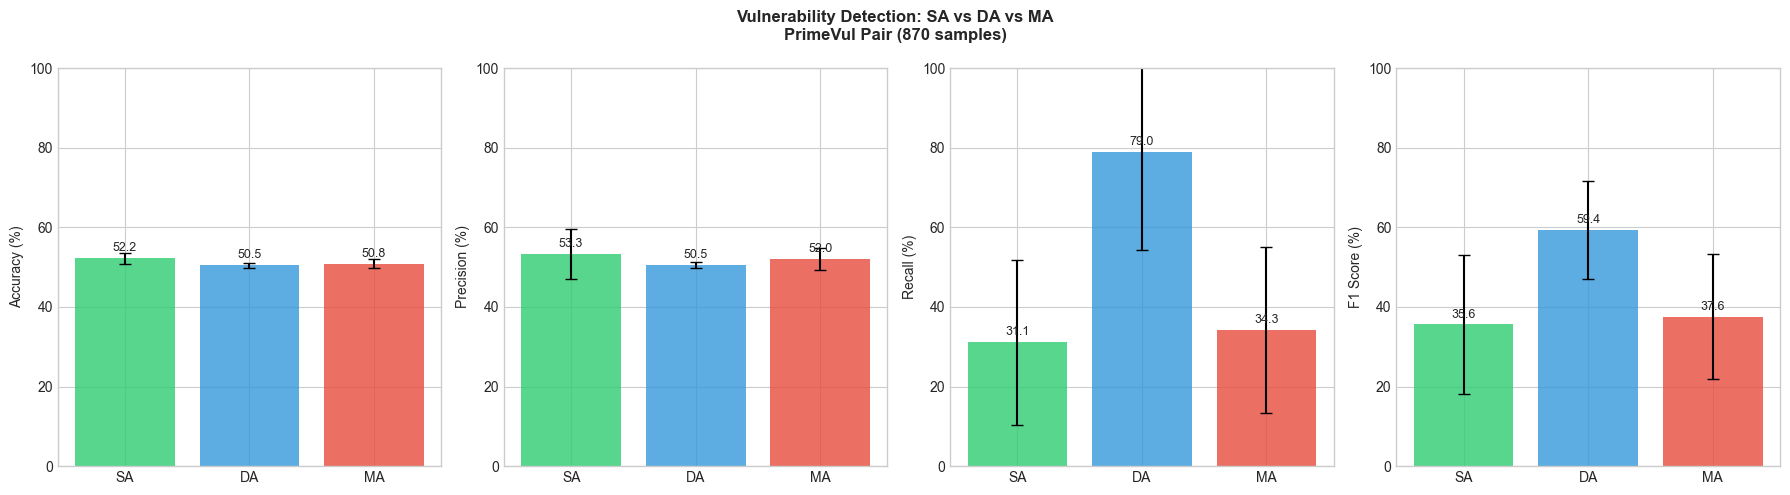

Saved: rq2_vuln_design_comparison_no_na


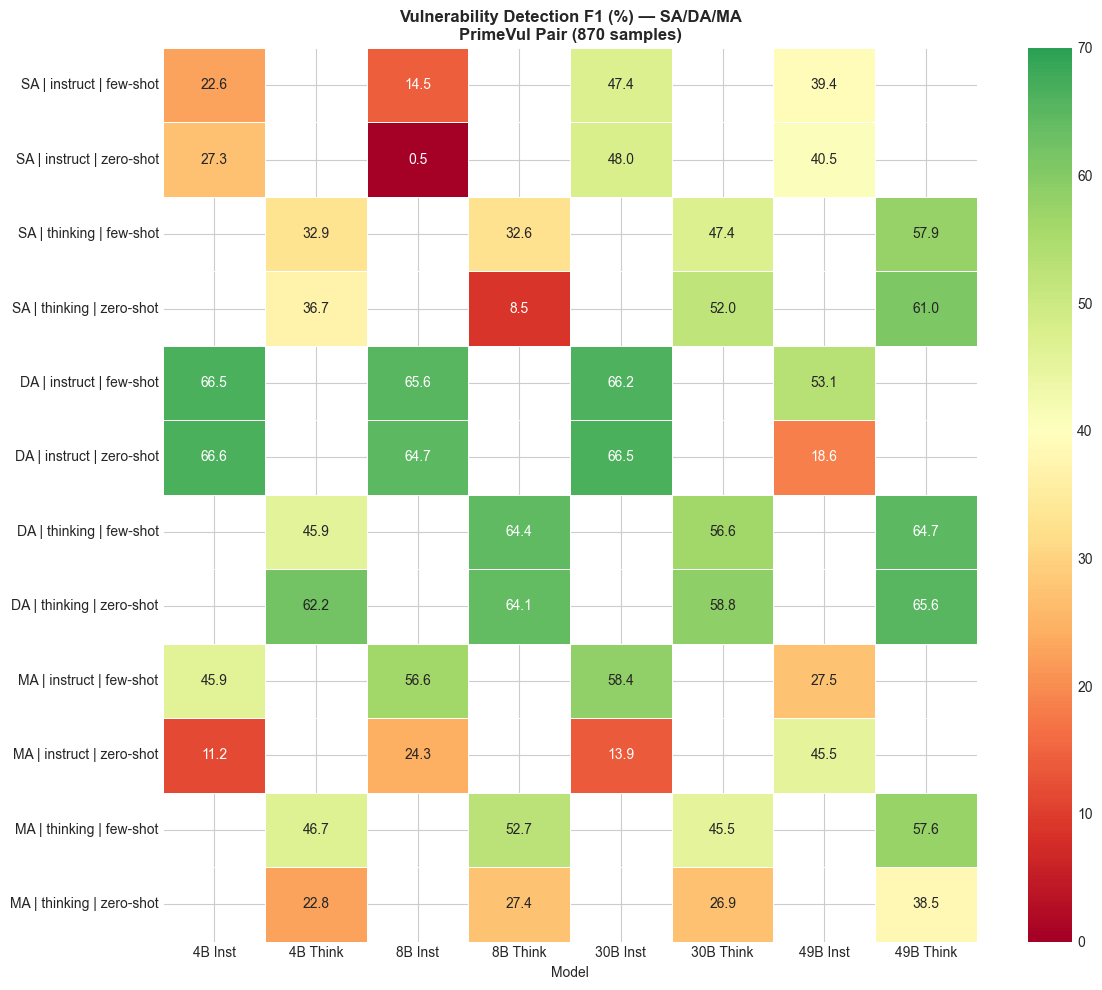

Saved: rq2_vuln_heatmap_no_na


In [15]:
# RQ2 figures: SA/DA/MA only (exclude NoAgent)
rq2_designs = ['SA', 'DA', 'MA']
rq2_colors = {'SA': '#2ecc71', 'DA': '#3498db', 'MA': '#e74c3c'}
rq2_df = df[df['design'].isin(rq2_designs)].copy()

# Bar chart: F1 by design (SA/DA/MA only)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_list = ['accuracy_pct', 'precision_pct', 'recall_pct', 'f1_score_pct']
metric_labels = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']

for ax, metric, label in zip(axes, metrics_list, metric_labels):
    means = rq2_df.groupby('design')[metric].mean().reindex(rq2_designs)
    stds = rq2_df.groupby('design')[metric].std().reindex(rq2_designs)
    bars = ax.bar(range(len(rq2_designs)), means, yerr=stds, capsize=4,
                  color=[rq2_colors[d] for d in rq2_designs], alpha=0.8)
    ax.set_xticks(range(len(rq2_designs)))
    ax.set_xticklabels(rq2_designs)
    ax.set_ylabel(label)
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Vulnerability Detection: SA vs DA vs MA\nPrimeVul Pair (870 samples)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_vuln_design_comparison_no_na.png', bbox_inches='tight', dpi=300)
plt.savefig(OUTPUT_DIR / 'rq2_vuln_design_comparison_no_na.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: rq2_vuln_design_comparison_no_na')

# Heatmap: SA/DA/MA only
rq2_df['config'] = rq2_df['design'] + ' | ' + rq2_df['mode'] + ' | ' + rq2_df['prompting']
hm = rq2_df.pivot_table(values='f1_score_pct', index='config', columns='model_short', aggfunc='mean')
design_sort = {'SA': 0, 'DA': 1, 'MA': 2}
hm['_sort'] = hm.index.map(lambda x: design_sort.get(x.split(' | ')[0], 99))
hm = hm.sort_values('_sort').drop(columns='_sort')
col_order = ['4B Inst', '4B Think', '8B Inst', '8B Think',
             '30B Inst', '30B Think', '49B Inst', '49B Think']
hm = hm[[c for c in col_order if c in hm.columns]]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(hm, annot=True, fmt='.1f', cmap='RdYlGn', center=40,
            linewidths=0.5, ax=ax, vmin=0, vmax=70)
ax.set_title('Vulnerability Detection F1 (%) — SA/DA/MA\nPrimeVul Pair (870 samples)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Model')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_vuln_heatmap_no_na.png', bbox_inches='tight', dpi=300)
plt.savefig(OUTPUT_DIR / 'rq2_vuln_heatmap_no_na.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: rq2_vuln_heatmap_no_na')


## 11. Export

In [16]:
# Save analysis data
export_cols = ['design', 'model', 'model_family', 'parameters_b', 'mode', 'prompting',
               'accuracy_pct', 'precision_pct', 'recall_pct', 'f1_score_pct',
               'true_positives', 'true_negatives', 'false_positives', 'false_negatives',
               'total_samples', 'fpr', 'fnr', 'total_energy_kwh', 'duration_hours', 'f1_per_kwh']
df[export_cols].sort_values(['design', 'model', 'mode', 'prompting']).to_csv(
    OUTPUT_DIR / 'vuln_detection_analysis.csv', index=False)

# Summary table
summary = df.groupby(['design', 'mode', 'prompting']).agg({
    'accuracy_pct': 'mean', 'f1_score_pct': 'mean', 'recall_pct': 'mean',
    'precision_pct': 'mean', 'total_energy_kwh': 'mean'
}).round(2)
summary.to_csv(OUTPUT_DIR / 'vuln_detection_summary.csv')
print(f'Saved to {OUTPUT_DIR}')
print(summary.to_string())

Saved to /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/notebooks/results
                            accuracy_pct  f1_score_pct  recall_pct  precision_pct  total_energy_kwh
design  mode     prompting                                                                         
DA      instruct few-shot          50.23         62.85       86.61          50.19              4.98
                 zero-shot         50.46         54.08       74.60          50.90              5.43
        thinking few-shot          50.86         57.87       70.80          50.69             14.49
                 zero-shot         50.26         62.67       83.79          50.20             15.41
MA      instruct few-shot          50.46         47.09       48.33          50.52             10.21
                 zero-shot         50.24         23.70       17.93          52.58             11.48
        thinking few-shot          51.95         50.64       50.17          52.32             27.99
       